In [1]:
from experiments.plot import MetricIdx, plot_metrics_vs_perturbation, plot_model_heatmap, plot_transferability, plot_images_side_by_side
from experiments.params import ExperimentTrainConfig, ExperimentEvalConfig
from utils.embedding import EmbedderName
from utils.dataset import DatasetName
from utils.vlm import VLMName
from pathlib import Path
import os

In [2]:
"""
to test perturbation plot (placeholder)
"""
# exp_config_train = ExperimentTrainConfig(
#     dataset_list=[DatasetName.VIDORE_SYN_AI],
#     embedder_list=[EmbedderName.CLIP_LARGE_PATCH14, EmbedderName.JINA_CLIP_2, EmbedderName.COLSMOL_500M],
#     vlm_list=[VLMName.SMOLVLM_1_256M, VLMName.SMOLVLM_1_500M],
#     max_perturbation_list=[x/255.0 for x in [8, 16]],
#     # save_folder = Path(__file__).parents[2] / "data/attacks/mac/",
#     save_folder = Path(os.path.abspath('')).parents[2] / "data/attacks/mac/",
#     n_gradient_steps=100,
# )
# exp_config_eval = ExperimentEvalConfig()

"""
to test perturbation plot (full x-axis)
"""
exp_config_train = ExperimentTrainConfig(
    dataset_list=[DatasetName.VIDORE_SYN_AI],
    embedder_list=[EmbedderName.CLIP_LARGE_PATCH14],
    vlm_list=[VLMName.SMOLVLM_1_2B],
    max_perturbation_list=[x/255.0 for x in [1, 2, 4, 8, 16, 32, 64, 128, 256]],
    save_folder = Path(os.path.abspath('')).parents[0] / "data/attacks/gpu/exp2/",
    n_gradient_steps=500,
)
exp_config_eval = ExperimentEvalConfig(
    results_folder = Path(os.path.abspath('')).parents[0] / "data/results/gpu/exp2/"
)

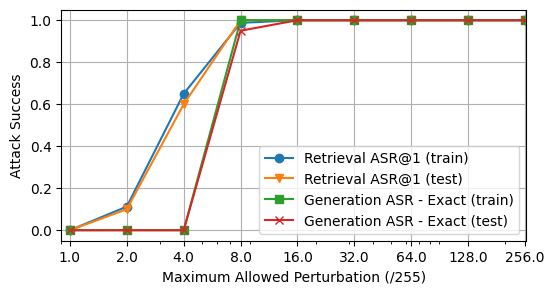

In [3]:
# need experiment -2
plot_metrics_vs_perturbation(exp_config_train, exp_config_eval, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TRAIN, MetricIdx.RETRIEVAL_ASR1_TEST, MetricIdx.GENERATION_ASR_EXACT_TRAIN, MetricIdx.GENERATION_ASR_EXACT_TEST])

In [4]:
"""
to test model heatmap
"""
exp_config_train = ExperimentTrainConfig(
    dataset_list=[DatasetName.VIDORE_SYN_AI],
    # dataset_list=[DatasetName.VIDORE_V2_ESG],
    embedder_list=[EmbedderName.CLIP_LARGE_PATCH14, EmbedderName.JINA_CLIP_2, EmbedderName.COLSMOL_500M],
    vlm_list=[VLMName.SMOLVLM_1_256M, VLMName.SMOLVLM_1_500M],
    max_perturbation_list=[x/255.0 for x in [8]],
    save_folder = Path(os.path.abspath('')).parents[2] / "data/attacks/mac/",
    n_gradient_steps=100,
)
exp_config_eval = ExperimentEvalConfig()

"""
Configuration  of figure 3
Bar Chart / Big Table: comparing different models
- should produce 8 images
- figure shows following metrics: recall_before, recall_after (avg train+test), retrieval_asr_train, retrieval_asr_test, generation_asr_train, generation_asr_test
- based on results -> we can run it again with higher or smaller max_perturbation    
"""
exp_config_train = ExperimentTrainConfig(
    dataset_list=[DatasetName.VIDORE_SYN_AI, DatasetName.VIDORE_V2_ESG],
    embedder_list=[EmbedderName.CLIP_LARGE_PATCH14, EmbedderName.JINA_CLIP_2, EmbedderName.COLPALI],
    vlm_list=[VLMName.SMOLVLM_1_2B, VLMName.QWEN_2p5_VL_3B],   
    save_folder = Path(os.path.abspath('')).parents[0] / "data/attacks/gpu/exp3/",     
)
exp_config_eval = ExperimentEvalConfig(
    results_folder = Path(os.path.abspath('')).parents[0] / "data/results/gpu/exp3/"
)

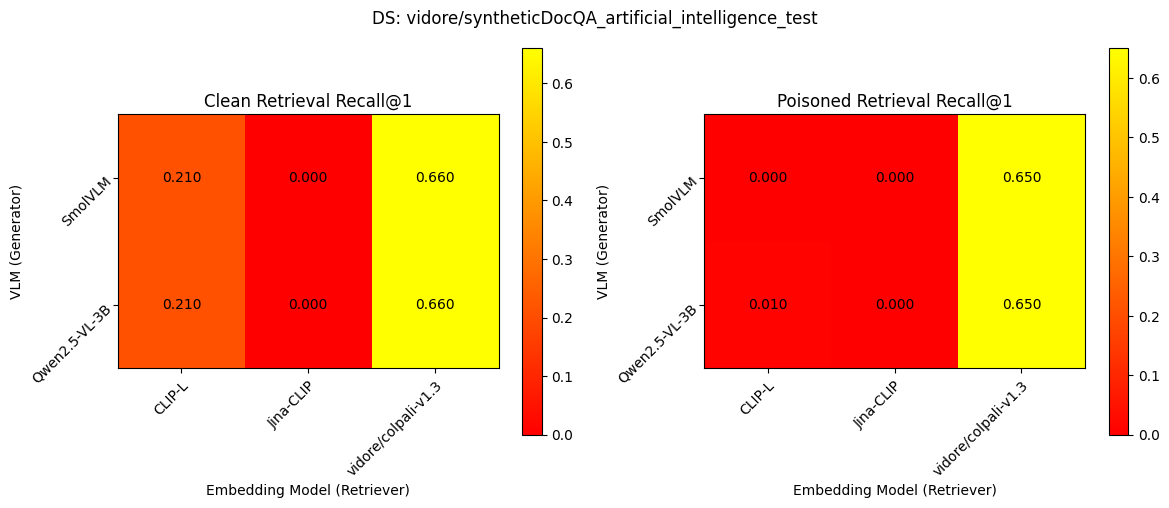

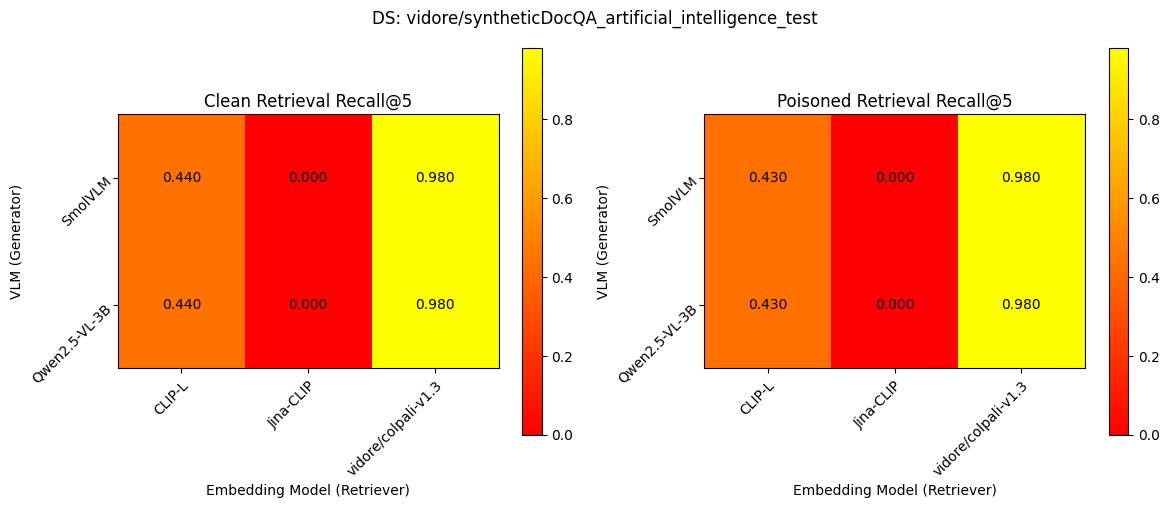

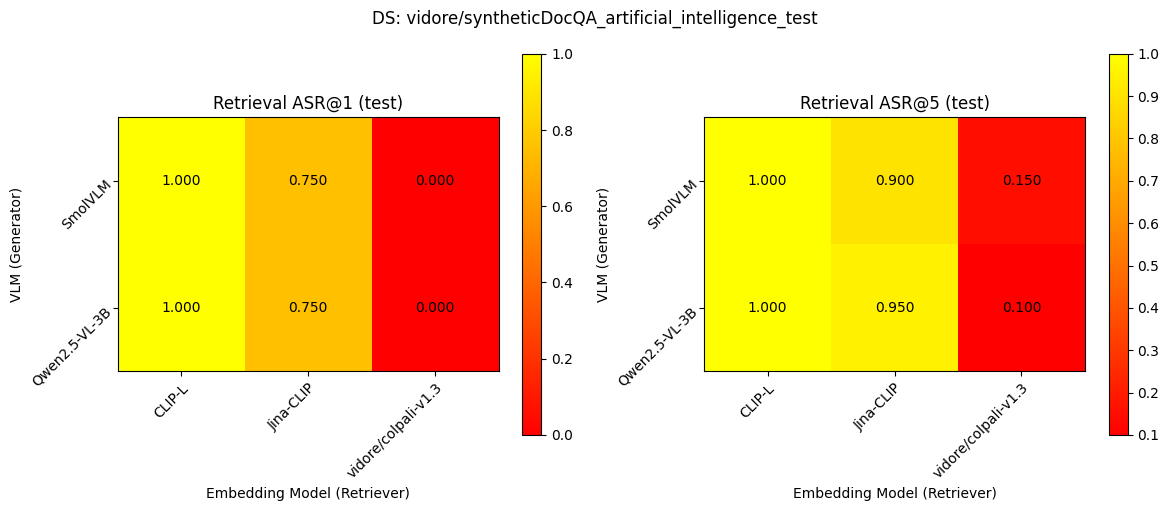

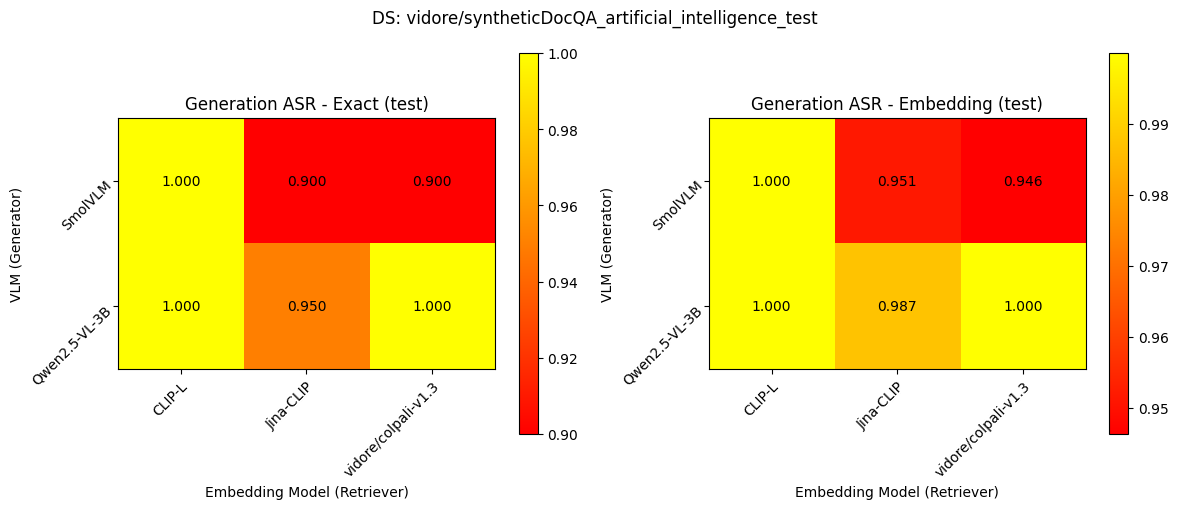

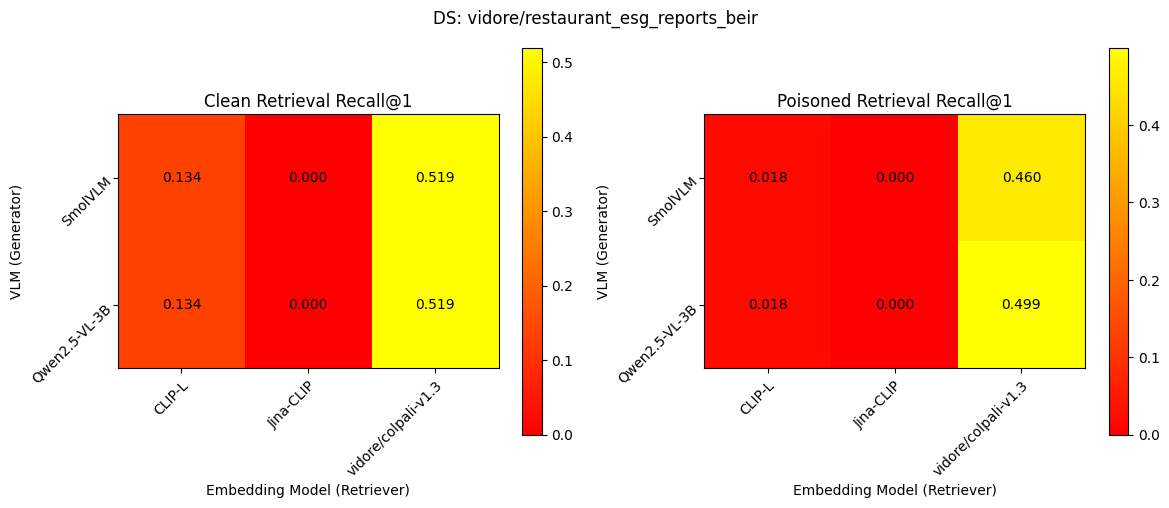

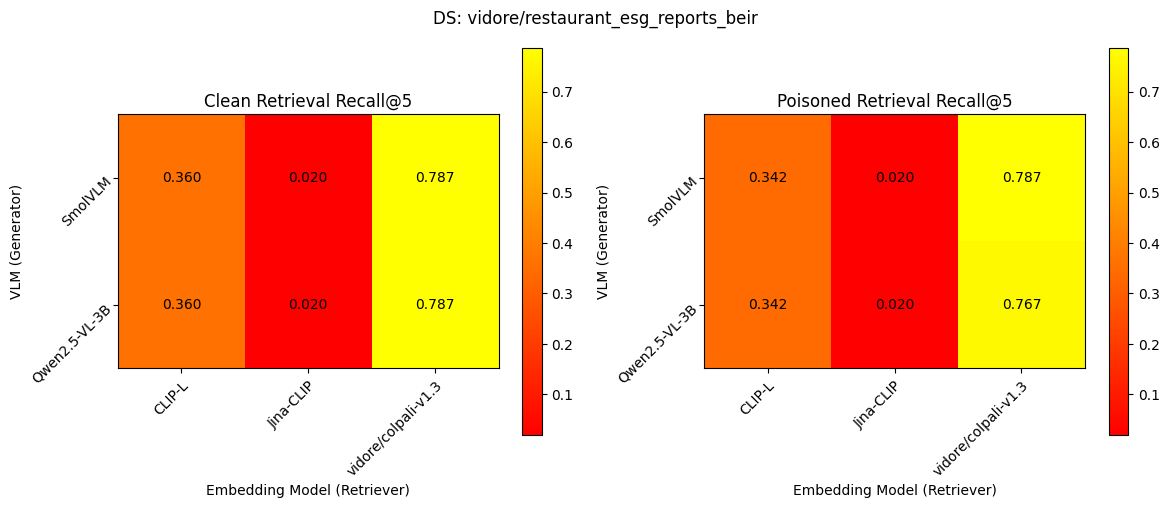

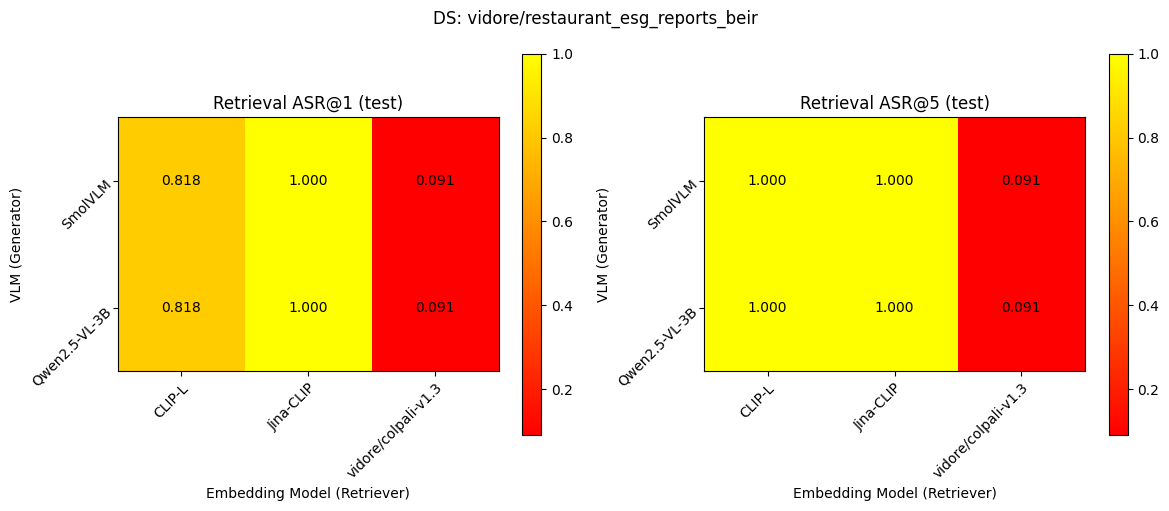

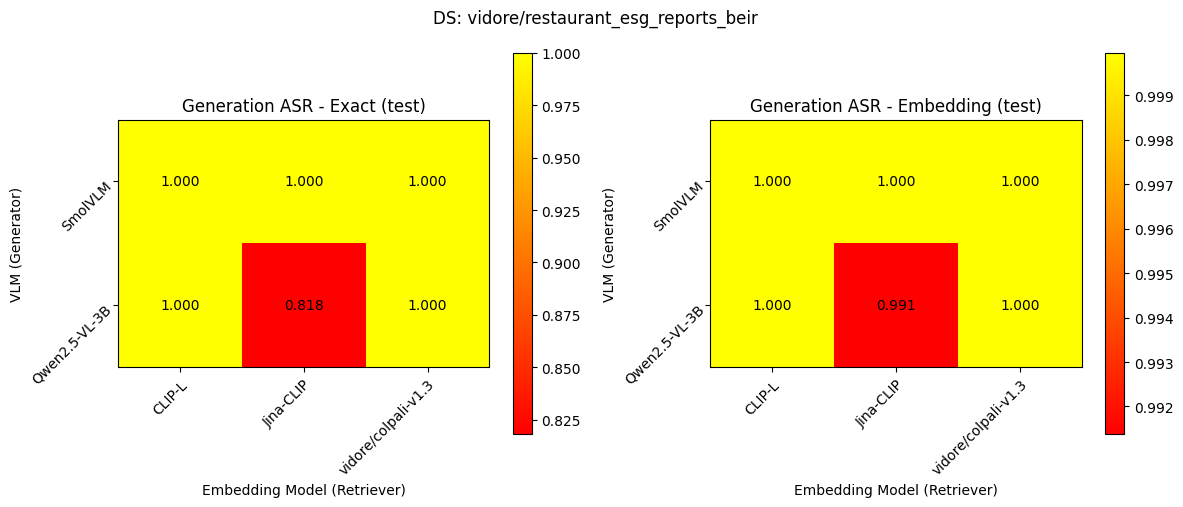

In [5]:
# need experiment -3
for ds_idx in range(2):
    plot_model_heatmap(exp_config_train, exp_config_eval, ds_idx=ds_idx, metrics_to_show=[MetricIdx.RETRIEVAL_RECALL1_BEFORE, MetricIdx.RETRIEVAL_RECALL1_AFTER])
    plot_model_heatmap(exp_config_train, exp_config_eval, ds_idx=ds_idx, metrics_to_show=[MetricIdx.RETRIEVAL_RECALL5_BEFORE, MetricIdx.RETRIEVAL_RECALL5_AFTER])
    plot_model_heatmap(exp_config_train, exp_config_eval, ds_idx=ds_idx, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TEST, MetricIdx.RETRIEVAL_ASR5_TEST])
    plot_model_heatmap(exp_config_train, exp_config_eval, ds_idx=ds_idx, metrics_to_show=[MetricIdx.GENERATION_ASR_EXACT_TEST, MetricIdx.GENERATION_ASR_EMBED_TEST])

In [8]:
"""
Configuration to test transferability (6x6)
"""
exp_config_train = ExperimentTrainConfig(
    embedder_list=[EmbedderName.CLIP_LARGE_PATCH14, EmbedderName.JINA_CLIP_2, EmbedderName.COLSMOL_500M],
    vlm_list=[VLMName.SMOLVLM_1_256M, VLMName.SMOLVLM_1_500M],
    save_folder = Path(os.path.abspath('')).parents[2] / "data/attacks/mac/"
)
exp_config_eval = ExperimentEvalConfig(
    eval_emb_list=[EmbedderName.CLIP_LARGE_PATCH14, EmbedderName.JINA_CLIP_2, EmbedderName.COLSMOL_500M],
    eval_vlm_list=[VLMName.SMOLVLM_1_256M, VLMName.SMOLVLM_1_500M]
)


"""
Configuration  of figure 4
Big Table: transferability between models (12 x 12 table, diagonals are white-box attacks) 
- should produce 8 x 8 images
- figure shows following metrics: recall_before, recall_after (avg train+test), retrieval_asr_train, retrieval_asr_test, generation_asr_train, generation_asr_test    
"""
exp_config_train = ExperimentTrainConfig(
    dataset_list=[DatasetName.VIDORE_SYN_AI, DatasetName.VIDORE_V2_ESG],
    embedder_list=[EmbedderName.CLIP_LARGE_PATCH14, EmbedderName.JINA_CLIP_2, EmbedderName.COLPALI],
    vlm_list=[VLMName.SMOLVLM_1_2B, VLMName.QWEN_2p5_VL_3B],
    save_folder = Path(os.path.abspath('')).parents[0] / "data/attacks/gpu/exp3/",
)
exp_config_eval = ExperimentEvalConfig(
    eval_emb_list=[EmbedderName.CLIP_LARGE_PATCH14, EmbedderName.JINA_CLIP_2, EmbedderName.COLPALI],
    eval_vlm_list=[VLMName.SMOLVLM_1_2B, VLMName.QWEN_2p5_VL_3B],
    results_folder = Path(os.path.abspath('')).parents[0] / "data/results/gpu/exp4/"
)

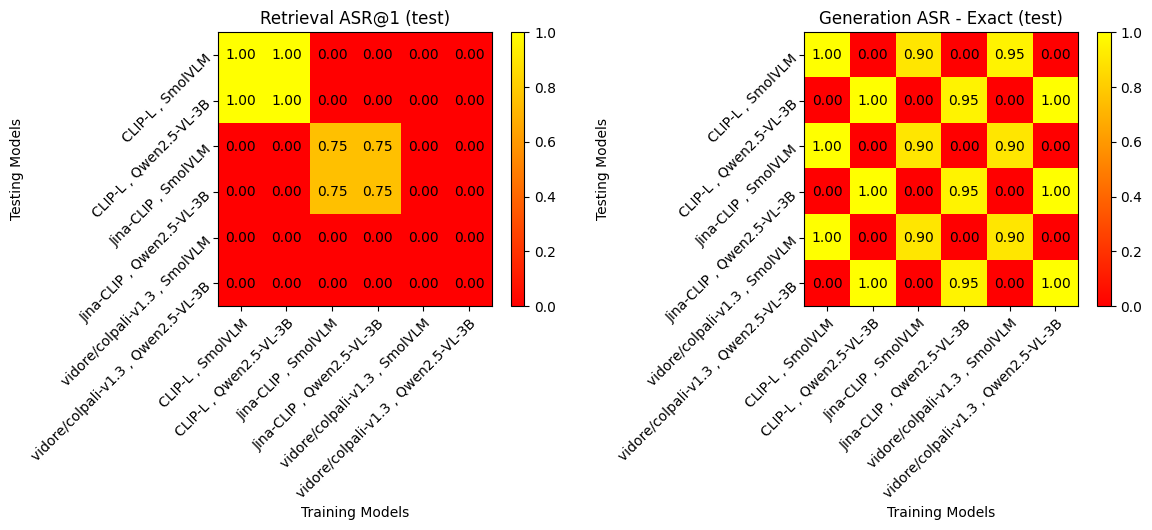

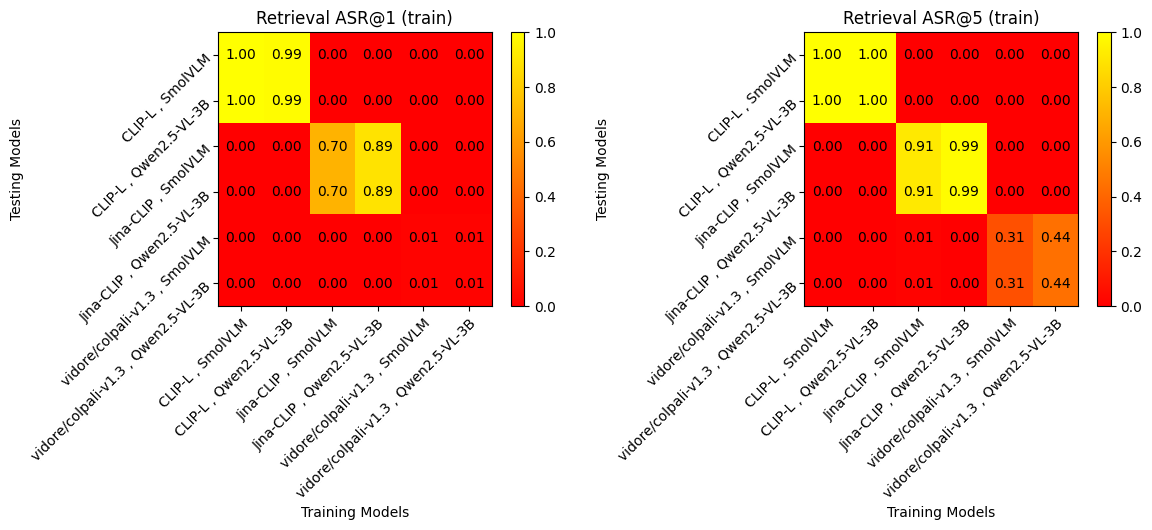

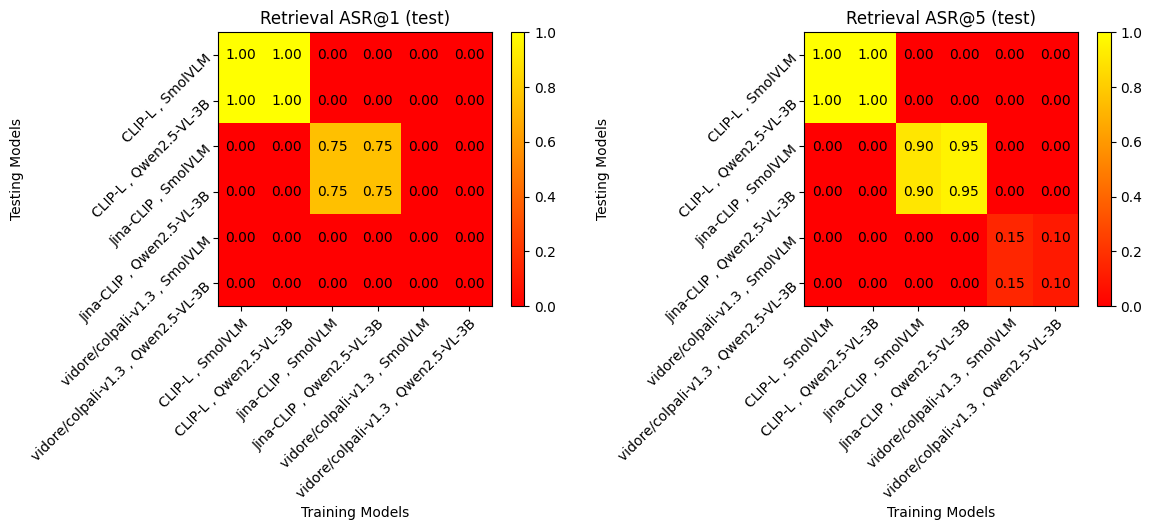

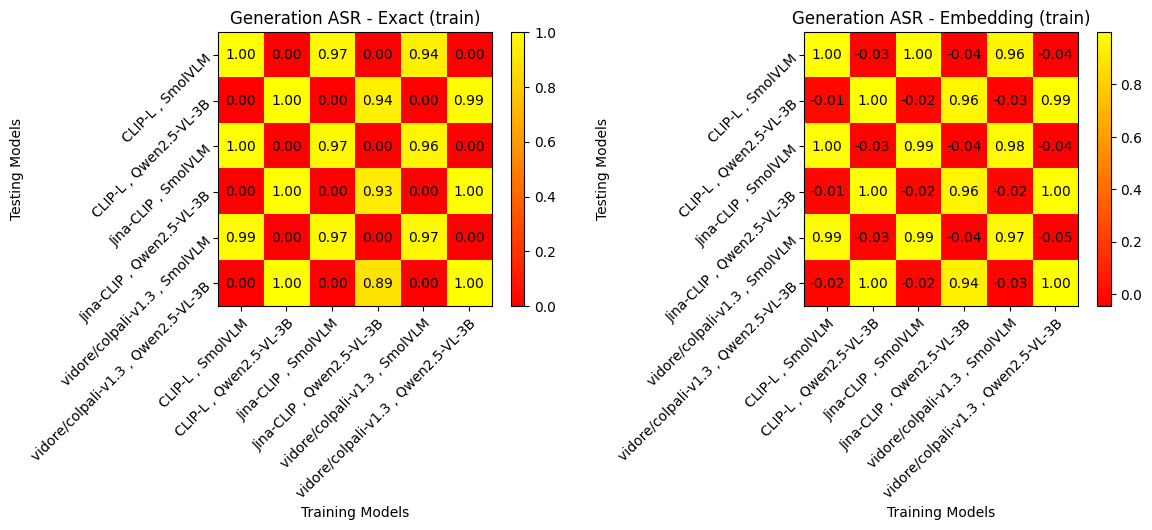

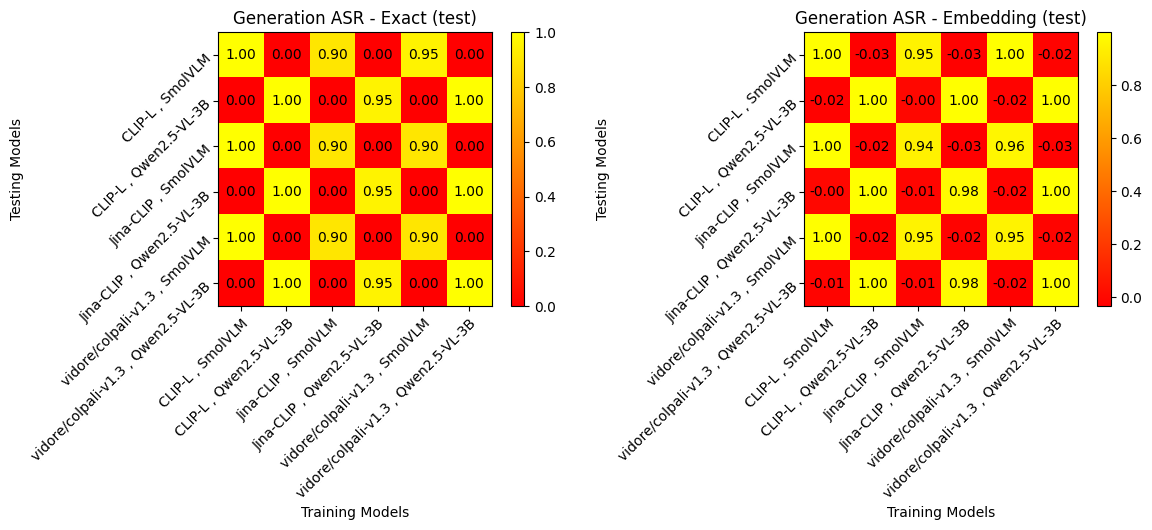

In [9]:
plot_transferability(exp_config_train, exp_config_eval, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TEST, MetricIdx.GENERATION_ASR_EXACT_TEST])
plot_transferability(exp_config_train, exp_config_eval, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TRAIN, MetricIdx.RETRIEVAL_ASR5_TRAIN])
plot_transferability(exp_config_train, exp_config_eval, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TEST, MetricIdx.RETRIEVAL_ASR5_TEST])
plot_transferability(exp_config_train, exp_config_eval, metrics_to_show=[MetricIdx.GENERATION_ASR_EXACT_TRAIN, MetricIdx.GENERATION_ASR_EMBED_TRAIN])
plot_transferability(exp_config_train, exp_config_eval, metrics_to_show=[MetricIdx.GENERATION_ASR_EXACT_TEST, MetricIdx.GENERATION_ASR_EMBED_TEST])

In [ ]:
"""
Configuration  to test showing images
- Qualitative demonstration showing non-attacked and attacked images on different base images
"""
# exp_config_train = ExperimentTrainConfig(
#     dataset_list=[DatasetName.VIDORE_SYN_AI, DatasetName.VIDORE_V2_ESG],
#     embedder_list=[EmbedderName.CLIP_LARGE_PATCH14],
#     vlm_list=[VLMName.SMOLVLM_1_256M],
#     save_folder = Path(os.path.abspath('')).parents[2] / "data/attacks/mac/"
# )
# exp_config_eval = ExperimentEvalConfig()

exp_config_train = ExperimentTrainConfig(
    dataset_list=[DatasetName.VIDORE_SYN_AI, DatasetName.VIDORE_V2_ESG],
    embedder_list=[EmbedderName.CLIP_LARGE_PATCH14],
    vlm_list=[VLMName.SMOLVLM_1_2B],
    save_folder=Path(os.path.abspath('')).parents[0] / "data/attacks/gpu/"
)
exp_config_eval = ExperimentEvalConfig(
    results_folder=Path(os.path.abspath('')).parents[0] / "data/results/gpu/"
)
print(Path(os.path.abspath('')).parents[0] / "data/attacks/gpu/")
print(Path(os.path.abspath('')).parents[0] / "data/results/gpu/")


/Users/ezaki/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/Research/LLMSec/code/mumorag_gh/mumoRAG-attacks/data/attacks/gpu
/Users/ezaki/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/Research/LLMSec/code/mumorag_gh/mumoRAG-attacks/data/results/gpu


In [ ]:
# need experiment -5
plot_images_side_by_side(exp_config_train, exp_config_eval, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TEST, MetricIdx.GENERATION_ASR_EXACT_TEST])

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ezaki/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/Research/LLMSec/code/mumorag_gh/mumoRAG-attacks/data/results/gpu/metrics_992adba301147c84faeabd0bfd4a8341.json'